In [1]:
from pathlib import Path
import json
import os
from collections import Counter
from collections import defaultdict

from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


GRAPH_ROOT = Path("../data/graphs")

# Plot
FIGSIZE = (10, 8)
POINT_SIZE = 20
ALPHA = 0.8

In [2]:
# ============================================================
# EMBEDDINGS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


def compute_pca(X, pca_components, feature_names=None, top_k=10):

    pca = PCA(
        n_components=pca_components,
    )

    embedding = pca.fit_transform(X)

    print("\nPCA explained variance ratio:")
    print(pca.explained_variance_ratio_)

    # --------------------------------------------------------
    # Feature importance per principal component
    # --------------------------------------------------------

    components = pca.components_  # shape: (n_components, n_features)

    if feature_names is None:
        feature_names = [f"f{i}" for i in range(X.shape[1])]

    for pc_idx, comp in enumerate(components):

        weights = np.abs(comp)
        top_idx = np.argsort(weights)[::-1][:top_k]

        print(f"\nPC{pc_idx + 1} top contributors:")

        for i in top_idx:
            print(f"  {feature_names[i]}: {comp[i]:.4f}")

    # --------------------------------------------------------
    # Global "energy" (aggregate loading strength)
    # --------------------------------------------------------

    energy = np.sum(
        (pca.explained_variance_ratio_[:, None] *
        np.abs(components)),
        axis=0
    )

    energy_df = pd.DataFrame({
        "feature": feature_names,
        "energy": energy,
    }).sort_values("energy", ascending=False)

    print("\nPCA Energy of Features:")
    print(energy_df)

    return embedding, pca, energy_df


# ============================================================
# VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np


def plot_tsne(
    X,
    labels,
    title=f"t-SNE Projection of Kernels",
    perplexity=30,
    cmap_name="tab10",
):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
    )

    embedding = tsne.fit_transform(X)

    plt.figure(figsize=FIGSIZE)

    unique_labels = sorted(set(labels))

    cmap = cm.get_cmap(cmap_name, len(unique_labels))

    for idx, label in enumerate(unique_labels):

        mask = labels == label

        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            s=POINT_SIZE,
            alpha=ALPHA,
            color=cmap(idx),
            label=label,
        )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)

    plt.legend()
    plt.tight_layout()

    plt.show()


def plot_tsne_continuous(
    X,
    labels,
    label_name,
    title=f"t-SNE Projection of Kernels",
    log_y=False,
    perplexity=30,
    cmap_name="tab10",
):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
    )

    embedding = tsne.fit_transform(X)

    labels = labels[label_name]
    if log_y:
        labels = np.where(labels == 0, 0, np.log(labels))

    cmap = cm.get_cmap(cmap_name)

    norm = colors.Normalize(vmin=np.min(labels), vmax=np.max(labels))

    plt.figure(figsize=FIGSIZE)

    sc = plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        s=POINT_SIZE,
        alpha=ALPHA,
        c=labels,
        cmap=cmap,
        norm=norm,
    )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)

    plt.colorbar(sc, label=label_name)

    plt.tight_layout()
    plt.show()

In [ ]:
import importlib
import features
importlib.reload(features)
from features import build_feature_dataframe

kernel_subset = ["2layer", "exemplar", "conv1d", "conv2d", "dense_latency", "dense_resource"]  # e.g. ["kernel1", "kernel2"] or None for all
#kernel_subset = ["dense_latency", "dense_resource"]
max_archives = 2
#df = build_feature_dataframe(GRAPH_ROOT, kernel_subset=kernel_subset, max_archives=max_archives)
df = df.fillna(0.0)

display(df.sample(n=20))
print()
print(df["kernel_type"].value_counts())

# --------------------------------------------------------
# Select features
# --------------------------------------------------------

exclude_cols = ["kernel_type", 'bram', 'cycles_max', 'cycles_min', 'dsp', 'estimated_clock', 'ff', 'interval_max', 'interval_min', 'lut', 'target_clock', 'uram']
feature_cols = [
    c for c in df.columns
    if c not in exclude_cols
]

X = df[feature_cols].values
y = df[exclude_cols]

# --------------------------------------------------------
# Normalize
# --------------------------------------------------------
X_scaled = StandardScaler().fit_transform(X)

Parsing graph files for kernel subset 'conv2d': 100%|██████████| 164/164 [01:09<00:00,  2.35it/s]
Parsing graph files for kernel subset 'dense_latency': 100%|██████████| 200/200 [01:00<00:00,  3.30it/s]
Parsing graph files for kernel subset 'dense_resource': 100%|██████████| 99/99 [00:32<00:00,  3.07it/s]


,num_nodes,num_edges,density,instruction_ratio,variable_ratio,constant_ratio,inst_control_inst_ratio,inst_data_var_ratio,var_data_inst_ratio,const_data_inst_ratio,...,op_fdiv,op_fpext,op_sitofp,op_fsub,op_fmul,op_fptrunc,op_fneg,op_fadd,op_udiv,op_sdiv
896,69185,124817,0.000026,0.513262,0.482431,0.004307,0.285987,0.246721,0.270901,0.101469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0
537,131085,238031,0.000014,0.510287,0.486463,0.003250,0.280333,0.246884,0.271019,0.111120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,91.0
388,39204,70354,0.000046,0.511785,0.483803,0.004413,0.286949,0.247434,0.273929,0.096654,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
763,72530,130952,0.000025,0.512671,0.483193,0.004136,0.286998,0.247679,0.270855,0.101060,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0
394,38145,68461,0.000047,0.511784,0.483890,0.004326,0.286192,0.246958,0.274039,0.097428,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
444,115920,210282,0.000016,0.509092,0.487621,0.003287,0.281745,0.249284,0.271683,0.111350,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,77.0
557,141505,257629,0.000013,0.509876,0.487170,0.002954,0.279029,0.246370,0.270711,0.112522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63.0,112.0
547,128094,231957,0.000014,0.510258,0.486143,0.003599,0.282712,0.248684,0.271490,0.110456,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.0,70.0
957,84573,152819,0.000021,0.513769,0.482175,0.004056,0.286888,0.246547,0.270444,0.100269,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0
679,56605,101839,0.000032,0.511616,0.483897,0.004487,0.287149,0.249963,0.272185,0.101886,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0



kernel_type
2layer            200
exemplar          200
dense_latency     200
conv2d            164
conv1d            111
dense_resource     99
Name: count, dtype: int64


In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
df.groupby("kernel_type").agg(["mean", "std", "min", "max"]).round(2)

num_nodes                           num_edges            \
                     mean       std    min     max       mean       std   
kernel_type                                                               
2layer           14987.51    242.71  14027   15139   26720.06    436.19   
conv1d          117883.33  22406.06  71878  169133  213962.63  40860.09   
conv2d          122316.63  21981.59  76613  162661  221915.15  40092.64   
dense_latency    75885.16  11814.98  45885  102524  137099.98  21405.01   
dense_resource   79064.36  12176.55  52878  109615  142788.99  22069.36   
exemplar         33891.82   7914.06  20506   40554   60779.73  14273.69   

                               density                instruction_ratio       \
                   min     max    mean  std  min  max              mean  std   
kernel_type                                                                    
2layer           24994   26991     0.0  0.0  0.0  0.0              0.51  0.0   
conv1d          130330  307519     0.0  0.0  0.0  0.0              0.51  0.0   
conv2d          138880  295429     0.0  0.0  0.0  0.0              0.51  0.0   
dense_latency    82850  185082     0.0  0.0  0.0  0.0              0.51  0.0   
dense_resource   95171  198142     0.0  0.0  0.0  0.0              0.51  0.0   
exemplar         36787   72841     0.0  0.0  0.0  0.0              0.51  0.0   

                           variable_ratio                  constant_ratio  \
                 min   max           mean  std   min   max           mean   
kernel_type                                                                 
2layer          0.51  0.51           0.48  0.0  0.48  0.48           0.01   
conv1d          0.51  0.51           0.49  0.0  0.48  0.49           0.00   
conv2d          0.51  0.51           0.49  0.0  0.48  0.49           0.00   
dense_latency   0.51  0.52           0.48  0.0  0.48  0.48           0.00   
dense_resource  0.51  0.52           0.48  0.0  0.48  0.48           0.00   
exemplar        0.51  0.51           0.48  0.0  0.48  0.48           0.01   

                                inst_control_inst_ratio                   \
                std   min   max                    mean  std   min   max   
kernel_type                                                                
2layer          0.0  0.01  0.01                    0.28  0.0  0.28  0.28   
conv1d          0.0  0.00  0.00                    0.28  0.0  0.28  0.28   
conv2d          0.0  0.00  0.00                    0.28  0.0  0.28  0.28   
dense_latency   0.0  0.00  0.01                    0.29  0.0  0.28  0.29   
dense_resource  0.0  0.00  0.00                    0.29  0.0  0.28  0.29   
exemplar        0.0  0.00  0.01                    0.29  0.0  0.28  0.29   

               inst_data_var_ratio                  var_data_inst_ratio       \
                              mean  std   min   max                mean  std   
kernel_type                                                                    
2layer                        0.25  0.0  0.24  0.25                0.27  0.0   
conv1d                        0.25  0.0  0.24  0.25                0.27  0.0   
conv2d                        0.25  0.0  0.25  0.25                0.27  0.0   
dense_latency                 0.25  0.0  0.24  0.25                0.27  0.0   
dense_resource                0.25  0.0  0.24  0.25                0.27  0.0   
exemplar                      0.25  0.0  0.24  0.25                0.27  0.0   

                           const_data_inst_ratio                   \
                 min   max                  mean  std   min   max   
kernel_type                                                         
2layer          0.27  0.27                  0.10  0.0  0.10  0.10   
conv1d          0.27  0.27                  0.11  0.0  0.11  0.11   
conv2d          0.27  0.27                  0.11  0.0  0.11  0.11   
dense_latency   0.27  0.27                  0.10  0.0  0.10  0.10   
dense_resource  0.27  0.27          


PCA explained variance ratio:
[0.69789864 0.09771526 0.08628291 0.05311711 0.03184507]

PC1 top contributors:
  num_nodes: 0.1387
  num_edges: 0.1387
  std_out_degree: 0.1387
  op_store: 0.1386
  max_out_degree: 0.1385
  op_load: 0.1384
  op_ptr: 0.1384
  max_width: 0.1384
  op_alloca: 0.1383
  op_ret: 0.1383
  max_in_degree: 0.1383
  op_icmp: 0.1380
  op_br: 0.1378
  op_call: 0.1377
  mean_width: 0.1372
  op_i1: 0.1370
  std_in_degree: 0.1369
  op_landingpad: 0.1360
  op_insertvalue: 0.1359
  op_resume: 0.1359

PC2 top contributors:
  op_sitofp: 0.3542
  op_fsub: 0.3542
  op_fadd: 0.3542
  op_fmul: 0.3542
  op_fptrunc: 0.3542
  op_fneg: 0.3542
  op_fpext: 0.2708
  op_fdiv: 0.2708
  op_double: 0.1986
  op_float: 0.1216
  inst_data_var_ratio: -0.1076
  inst_control_inst_ratio: -0.0853
  mean_in_degree: 0.0473
  mean_out_degree: 0.0473
  op_; undefined function: 0.0420
  op_sdiv: 0.0399
  op_ptrtoint: 0.0393
  op_udiv: 0.0387
  op_mul: 0.0375
  constant_ratio: -0.0373

PC3 top contribut

/tmp/ipykernel_6665/2839354802.py:93: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(unique_labels))


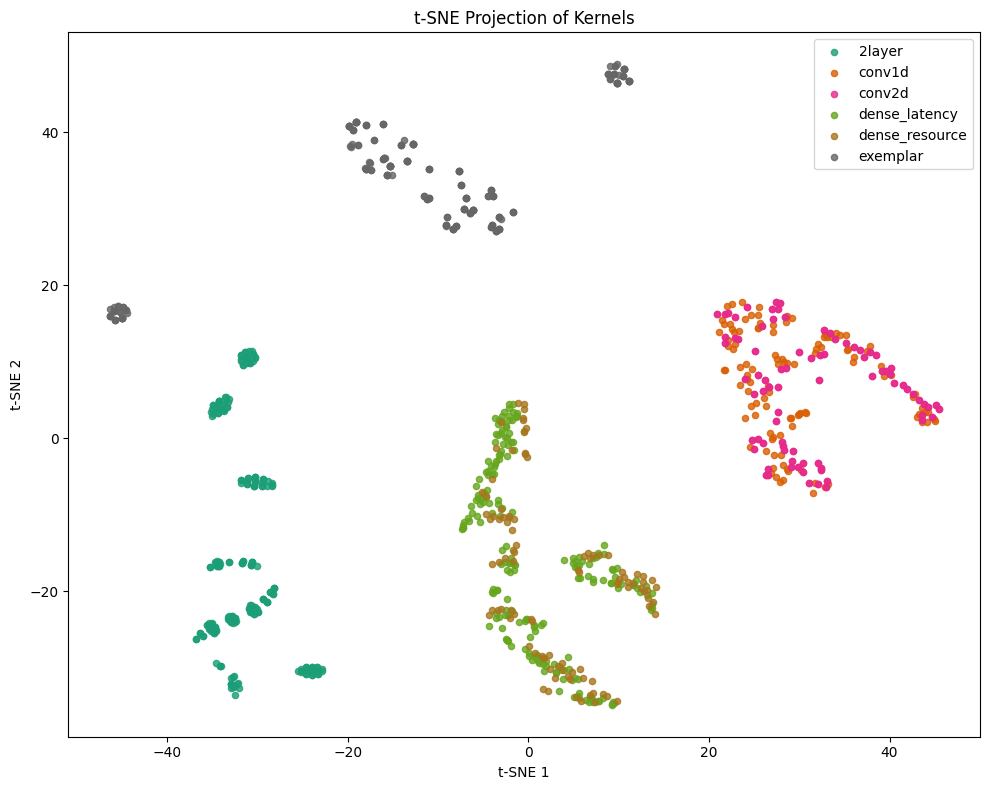

/home/brend/anaconda3/envs/pipeline-env/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_6665/2839354802.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


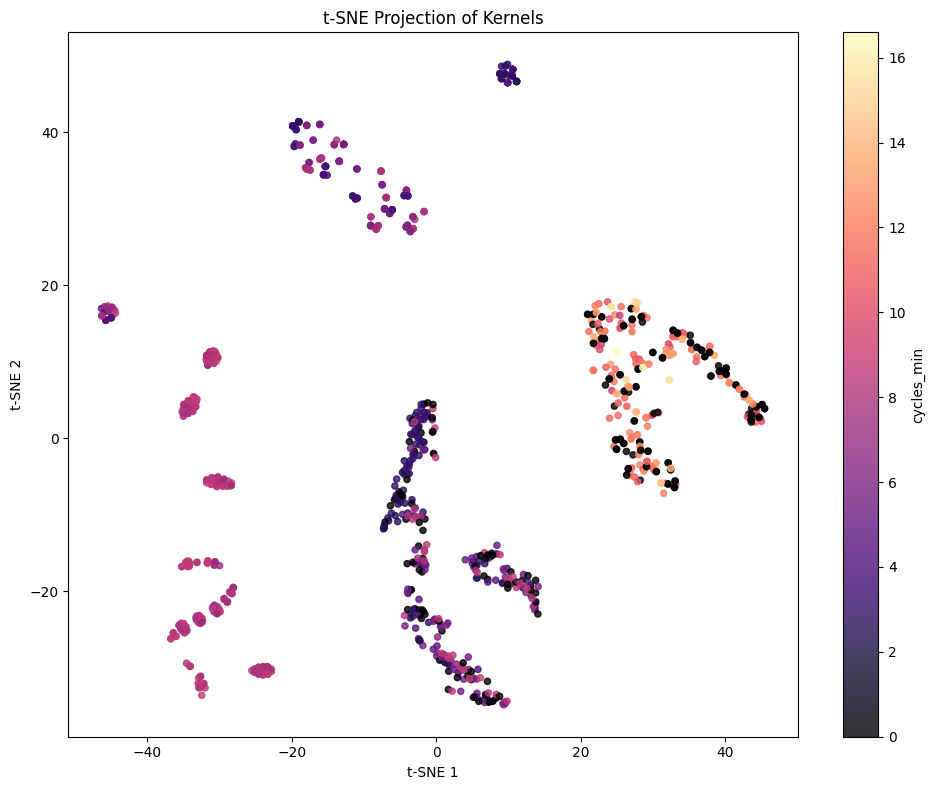

In [13]:
pca_components = 5
embedding, pca, energy_df = compute_pca(X_scaled, pca_components, feature_names=feature_cols, top_k=20)

plot_tsne(embedding, y['kernel_type'], cmap_name="Dark2")
plot_tsne_continuous(embedding, y, label_name='cycles_min', log_y=True, cmap_name="magma")

In [ ]:
def between_class_variance_ratio(X, labels, feature_names):
    """
    For each feature: how much of its total variance is explained
    by differences between group means? Range [0, 1].
    1.0 = feature perfectly separates groups, 0.0 = no separation.
    """
    unique_labels = np.unique(labels)
    global_mean = X.mean(axis=0)
    total_var = X.var(axis=0)

    class_means = np.array([X[labels == k].mean(axis=0) for k in unique_labels])
    class_counts = np.array([np.sum(labels == k) for k in unique_labels])

    # weighted variance of class means around global mean
    between_var = np.average(
        (class_means - global_mean) ** 2,
        axis=0,
        weights=class_counts / len(labels)
    )

    ratio = np.where(total_var > 0, between_var / total_var, 0.0)

    return pd.DataFrame({
        "feature": feature_names,
        "between_class_var_ratio": ratio,
    }).sort_values("between_class_var_ratio", ascending=False)

bcvr_df = between_class_variance_ratio(X_scaled, y["kernel_type"], feature_cols)
bcvr_df

/tmp/ipykernel_67302/1330541545.py:21: RuntimeWarning: invalid value encountered in divide
  ratio = np.where(total_var > 0, between_var / total_var, 0.0)


,feature,between_class_var_ratio
17,critical_path_depth,1.000000
20,total_levels,1.000000
40,opcode_count_; undefined function,0.993125
9,const_data_inst_ratio,0.974973
62,opcode_count_switch,0.960085
2,density,0.958441
11,mean_in_degree,0.936903
14,mean_out_degree,0.936903
16,std_out_degree,0.933540
13,std_in_degree,0.926727


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
embedding_lda = lda.fit_transform(X_scaled, y["kernel_type"])

# coef_ gives you the feature weights per discriminant axis
lda_weights = pd.DataFrame({
    "feature": feature_cols,
    "LD1": np.abs(lda.coef_[0]),
}).sort_values("LD1", ascending=False)
lda_weights

,feature,LD1
17,critical_path_depth,5.803453e+28
20,total_levels,5.803453e+28
1,num_edges,6.586801e+06
12,max_in_degree,3.518502e+06
31,opcode_count_ret,2.963234e+06
22,opcode_count_alloca,1.046124e+06
35,opcode_count_store,9.627142e+05
27,opcode_count_getelementptr,8.457014e+05
30,opcode_count_call,6.871400e+05
0,num_nodes,5.436771e+05
